# PCI Sensitivity Notebook

Simple one-at-a-time sensitivity for `d50`, `na`, and rainfall excess `r`.

This notebook keeps `alpha` fixed from `config/montecito.yaml`. It writes deterministic threshold maps, a scenario summary CSV, a Monte Carlo PCI raster, and PCI source polygons.

In [2]:
from pathlib import Path
import sys

REPO = Path.cwd()

if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

print(REPO)
print(REPO / "src")

/home/abdullah/pci-source-zones
/home/abdullah/pci-source-zones/src


In [3]:
from pathlib import Path
from pci_source_zones.config import load_config, resolve_path

cfg = load_config("config/montecito.yaml")

dem_path = resolve_path(cfg, cfg["paths"]["dem"])

print("DEM path:", dem_path)
print("DEM exists:", dem_path.exists())

DEM path: /mnt/c/Users/amehedi/Downloads/thomas/topographic__elevation.tif
DEM exists: True


In [4]:
from pathlib import Path
import csv
import sys

import numpy as np

REPO = Path.cwd()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from pci_source_zones.config import load_config, output_path
from pci_source_zones.terrain import prepare_terrain
from pci_source_zones.inputs import InputProvider, read_raster, write_raster
from pci_source_zones.c_model import modeled_threshold_c
from pci_source_zones.monte_carlo import compute_pci_monte_carlo
from pci_source_zones.polygons import extract_source_polygons

cfg = load_config("config/montecito.yaml")

OUT = Path(cfg["paths"]["output_dir"]) / "sensitivity"
OUT.mkdir(parents=True, exist_ok=True)

print("repo:", REPO)
print("outputs:", OUT)

repo: /home/abdullah/pci-source-zones
outputs: /mnt/c/Users/amehedi/Downloads/sensitivity


## 1. Prepare terrain once

This computes or reuses `G = aS^alpha`. The sensitivity below changes only `d50`, `na`, and `r`.

In [5]:
g_path = output_path(cfg, "topographic_driving_index", "topographic_driving_index.tif")

if not g_path.exists():
    print("G raster not found. Preparing terrain from DEM...")
    prepare_terrain(cfg)
else:
    print("Using existing G raster:", g_path)

G, profile = read_raster(g_path)
valid = np.isfinite(G)
cell_area_m2 = abs(profile["transform"].a * profile["transform"].e)

print("valid cells:", int(valid.sum()))
print("cell area m2:", cell_area_m2)
print("G min/mean/max:", float(np.nanmin(G)), float(np.nanmean(G)), float(np.nanmax(G)))

Using existing G raster: /mnt/c/Users/amehedi/Downloads/topographic_driving_index.tif
valid cells: 579712
cell area m2: 100.0
G min/mean/max: 0.0 261.84342867141896 1108000.875


## 2. Baseline and one-at-a-time scenarios

In [6]:
baseline = {
    "d50_mm": 2.0,
    "na": 0.052,
    "r_mm_hr": 35.0,
}

scenarios = []
scenarios.append({"group": "baseline", "name": "baseline", **baseline})

for value in [1.3, 2.0, 2.9]:
    scenarios.append({"group": "d50", "name": f"d50_{value:g}mm", **baseline, "d50_mm": value})

for value in [0.01, 0.052, 0.10]:
    scenarios.append({"group": "na", "name": f"na_{value:g}", **baseline, "na": value})

for value in [15.0, 35.0, 55.0]:
    scenarios.append({"group": "r", "name": f"r_{value:g}mmhr", **baseline, "r_mm_hr": value})

# Drop exact duplicate baseline rows from the one-at-a-time groups.
seen = set()
unique_scenarios = []
for s in scenarios:
    key = (s["d50_mm"], s["na"], s["r_mm_hr"])
    if key in seen:
        continue
    seen.add(key)
    unique_scenarios.append(s)

scenarios = unique_scenarios
scenarios

[{'group': 'baseline',
  'name': 'baseline',
  'd50_mm': 2.0,
  'na': 0.052,
  'r_mm_hr': 35.0},
 {'group': 'd50',
  'name': 'd50_1.3mm',
  'd50_mm': 1.3,
  'na': 0.052,
  'r_mm_hr': 35.0},
 {'group': 'd50',
  'name': 'd50_2.9mm',
  'd50_mm': 2.9,
  'na': 0.052,
  'r_mm_hr': 35.0},
 {'group': 'na',
  'name': 'na_0.01',
  'd50_mm': 2.0,
  'na': 0.01,
  'r_mm_hr': 35.0},
 {'group': 'na', 'name': 'na_0.1', 'd50_mm': 2.0, 'na': 0.1, 'r_mm_hr': 35.0},
 {'group': 'r',
  'name': 'r_15mmhr',
  'd50_mm': 2.0,
  'na': 0.052,
  'r_mm_hr': 15.0},
 {'group': 'r',
  'name': 'r_55mmhr',
  'd50_mm': 2.0,
  'na': 0.052,
  'r_mm_hr': 55.0}]

In [7]:
def d50_mm_to_m(value_mm):
    return value_mm / 1000.0


def r_mm_hr_to_m_s(value_mm_hr):
    return value_mm_hr / 1000.0 / 3600.0


def source_area_m2(binary_map):
    return float(np.nansum(binary_map) * cell_area_m2)


def save_binary_map(path, binary_map):
    write_raster(path, binary_map.astype("float32"), profile)


summary = []

for scenario in scenarios:
    c_value = float(
        modeled_threshold_c(
            d50_mm_to_m(scenario["d50_mm"]),
            scenario["na"],
            r_mm_hr_to_m_s(scenario["r_mm_hr"]),
            cfg["parameters"],
        )
    )
    binary = np.full(G.shape, np.nan, dtype="float32")
    binary[valid] = (G[valid] > c_value).astype("float32")

    map_path = OUT / f"binary_source_{scenario['name']}.tif"
    save_binary_map(map_path, binary)

    summary.append(
        {
            "group": scenario["group"],
            "name": scenario["name"],
            "d50_mm": scenario["d50_mm"],
            "na": scenario["na"],
            "r_mm_hr": scenario["r_mm_hr"],
            "C_model": c_value,
            "source_cells": int(np.nansum(binary)),
            "source_area_m2": source_area_m2(binary),
            "map": str(map_path),
        }
    )

summary_csv = OUT / "deterministic_sensitivity_summary.csv"
with summary_csv.open("w", newline="", encoding="utf-8") as f:
    writer = csv.DictWriter(f, fieldnames=list(summary[0].keys()))
    writer.writeheader()
    writer.writerows(summary)

print("wrote:", summary_csv)
summary

wrote: /mnt/c/Users/amehedi/Downloads/sensitivity/deterministic_sensitivity_summary.csv


[{'group': 'baseline',
  'name': 'baseline',
  'd50_mm': 2.0,
  'na': 0.052,
  'r_mm_hr': 35.0,
  'C_model': 19.52604276024623,
  'source_cells': 223384,
  'source_area_m2': 22338400.0,
  'map': '/mnt/c/Users/amehedi/Downloads/sensitivity/binary_source_baseline.tif'},
 {'group': 'd50',
  'name': 'd50_1.3mm',
  'd50_mm': 1.3,
  'na': 0.052,
  'r_mm_hr': 35.0,
  'C_model': 11.10781182729088,
  'source_cells': 308751,
  'source_area_m2': 30875100.0,
  'map': '/mnt/c/Users/amehedi/Downloads/sensitivity/binary_source_d50_1.3mm.tif'},
 {'group': 'd50',
  'name': 'd50_2.9mm',
  'd50_mm': 2.9,
  'na': 0.052,
  'r_mm_hr': 35.0,
  'C_model': 31.79942886693813,
  'source_cells': 150026,
  'source_area_m2': 15002600.0,
  'map': '/mnt/c/Users/amehedi/Downloads/sensitivity/binary_source_d50_2.9mm.tif'},
 {'group': 'na',
  'name': 'na_0.01',
  'd50_mm': 2.0,
  'na': 0.01,
  'r_mm_hr': 35.0,
  'C_model': 4.751181199109224,
  'source_cells': 415661,
  'source_area_m2': 41566100.0,
  'map': '/mnt/c/User

## 3. Monte Carlo PCI

This uses the paper-style uncertainty ranges for `d50`, `na`, and `r`. It writes `C_mean`, `PCI`, and source polygons at PCI thresholds 0.6 and 0.7.

In [8]:
n_samples = 1500
seed = 42

d50_mc = InputProvider(
    {"mode": "distribution", "distribution": "lognormal", "mean": 2.0, "std": 0.48, "units": "mm"},
    "d50",
    cfg,
    reference_shape=G.shape,
)
na_mc = InputProvider(
    {"mode": "distribution", "distribution": "uniform", "min": 0.015, "max": 0.10, "units": "manning"},
    "na",
    cfg,
    reference_shape=G.shape,
)
r_mc = InputProvider(
    {"mode": "distribution", "distribution": "uniform", "min": 15.0, "max": 55.0, "units": "mm/hr"},
    "rainfall_excess",
    cfg,
    reference_shape=G.shape,
)

pci, c_mean = compute_pci_monte_carlo(
    G,
    d50_mc,
    na_mc,
    r_mc,
    cfg["parameters"],
    n_samples=n_samples,
    seed=seed,
    valid_mask=valid,
)

c_mean_path = OUT / "monte_carlo_c_mean.tif"
pci_path = OUT / "monte_carlo_pci.tif"
write_raster(c_mean_path, c_mean, profile)
write_raster(pci_path, pci, profile)

for threshold in [0.6, 0.7]:
    gpkg_path = OUT / f"source_polygons_pci_{threshold:.1f}.gpkg"
    gdf = extract_source_polygons(
        pci,
        profile,
        threshold=threshold,
        min_area_m2=float(cfg["outputs"].get("min_area_m2", 0.0)),
        out_path=gpkg_path,
    )
    print(f"PCI >= {threshold}: {len(gdf)} polygons -> {gpkg_path}")

print("wrote:", c_mean_path)
print("wrote:", pci_path)
print("PCI min/mean/max:", float(np.nanmin(pci)), float(np.nanmean(pci)), float(np.nanmax(pci)))

PCI >= 0.6: 13888 polygons -> /mnt/c/Users/amehedi/Downloads/sensitivity/source_polygons_pci_0.6.gpkg
PCI >= 0.7: 14697 polygons -> /mnt/c/Users/amehedi/Downloads/sensitivity/source_polygons_pci_0.7.gpkg
wrote: /mnt/c/Users/amehedi/Downloads/sensitivity/monte_carlo_c_mean.tif
wrote: /mnt/c/Users/amehedi/Downloads/sensitivity/monte_carlo_pci.tif
PCI min/mean/max: 0.0 0.38166060503606386 1.0


## 4. Quick plots

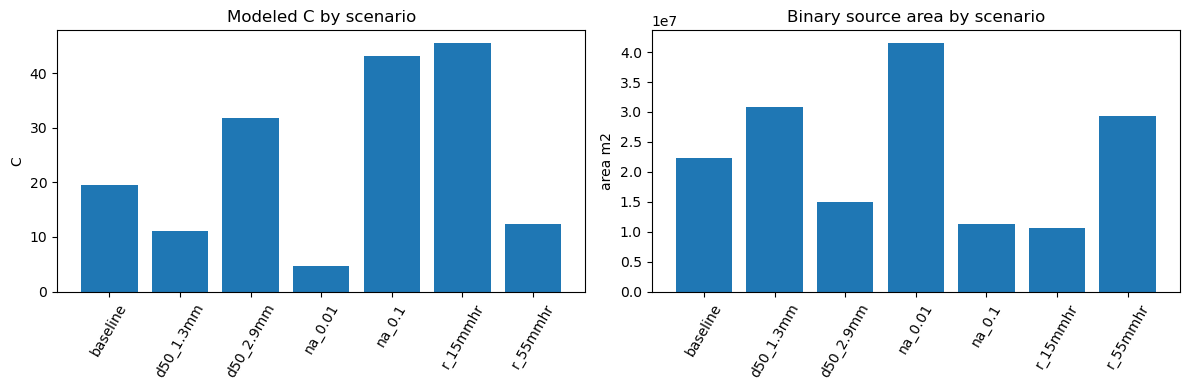

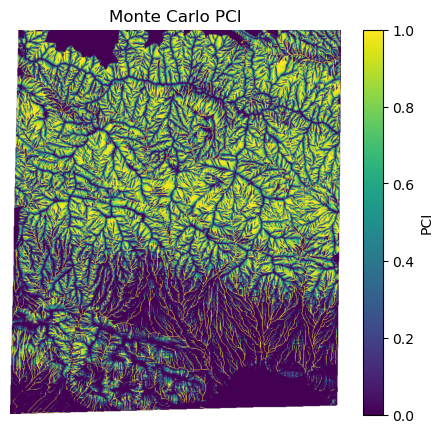

In [9]:
import matplotlib.pyplot as plt

names = [row["name"] for row in summary]
areas = [row["source_area_m2"] for row in summary]
c_values = [row["C_model"] for row in summary]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(names, c_values)
axes[0].set_title("Modeled C by scenario")
axes[0].set_ylabel("C")
axes[0].tick_params(axis="x", rotation=60)

axes[1].bar(names, areas)
axes[1].set_title("Binary source area by scenario")
axes[1].set_ylabel("area m2")
axes[1].tick_params(axis="x", rotation=60)
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 5))
plt.imshow(pci, vmin=0, vmax=1)
plt.colorbar(label="PCI")
plt.title("Monte Carlo PCI")
plt.axis("off")
plt.show()

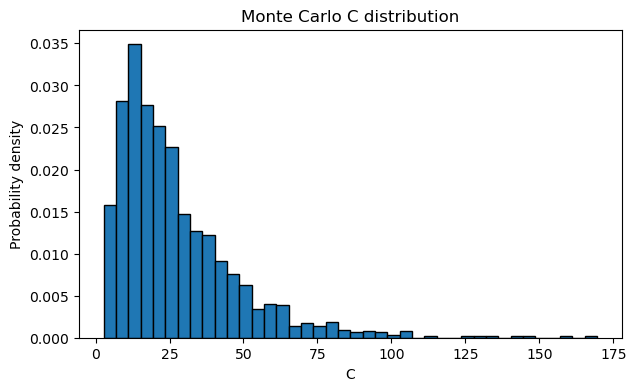

C min: 2.7916054336908154
C mean: 27.10995654632979
C median: 21.958701813857424
C max: 169.4691068018139


In [10]:
import numpy as np
import matplotlib.pyplot as plt

n_samples = 1500
rng = np.random.default_rng(42)

# Sample input variables
d50_samples_mm = rng.lognormal(
    mean=np.log(2.0),
    sigma=0.24,
    size=n_samples,
)

na_samples = rng.uniform(
    low=0.015,
    high=0.10,
    size=n_samples,
)

r_samples_mm_hr = rng.uniform(
    low=15,
    high=55,
    size=n_samples,
)

# Convert units
d50_samples_m = d50_samples_mm / 1000
r_samples_m_s = r_samples_mm_hr / 1000 / 3600

# Calculate C for each sample
C_samples = []

for d50, na, r in zip(d50_samples_m, na_samples, r_samples_m_s):
    C = modeled_threshold_c(d50, na, r, cfg["parameters"])
    C_samples.append(float(C))

C_samples = np.array(C_samples)

plt.figure(figsize=(7, 4))

plt.hist(
    C_samples,
    bins=40,
    density=True,
    edgecolor="black"
)

plt.xlabel("C")
plt.ylabel("Probability density")
plt.title("Monte Carlo C distribution")
plt.show()

print("C min:", C_samples.min())
print("C mean:", C_samples.mean())
print("C median:", np.median(C_samples))
print("C max:", C_samples.max())

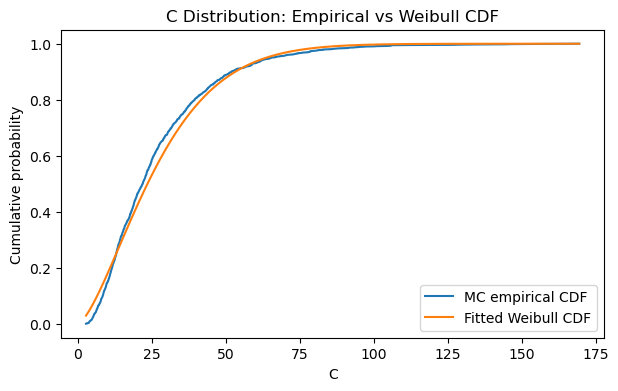

Weibull shape: 1.4716319751165052
Weibull scale: 30.198169301827658
Weibull loc: 0


In [11]:
from scipy.stats import weibull_min
import numpy as np
import matplotlib.pyplot as plt

# Fit Weibull to C samples
shape, loc, scale = weibull_min.fit(C_samples, floc=0)

# X values for plotting
x = np.linspace(C_samples.min(), C_samples.max(), 300)

# Weibull CDF
weibull_cdf = weibull_min.cdf(x, shape, loc=loc, scale=scale)

# Empirical CDF from your Monte Carlo samples
C_sorted = np.sort(C_samples)
empirical_cdf = np.arange(1, len(C_sorted) + 1) / len(C_sorted)

plt.figure(figsize=(7, 4))

plt.plot(C_sorted, empirical_cdf, label="MC empirical CDF")
plt.plot(x, weibull_cdf, label="Fitted Weibull CDF")

plt.xlabel("C")
plt.ylabel("Cumulative probability")
plt.title("C Distribution: Empirical vs Weibull CDF")
plt.legend()
plt.show()

print("Weibull shape:", shape)
print("Weibull scale:", scale)
print("Weibull loc:", loc)

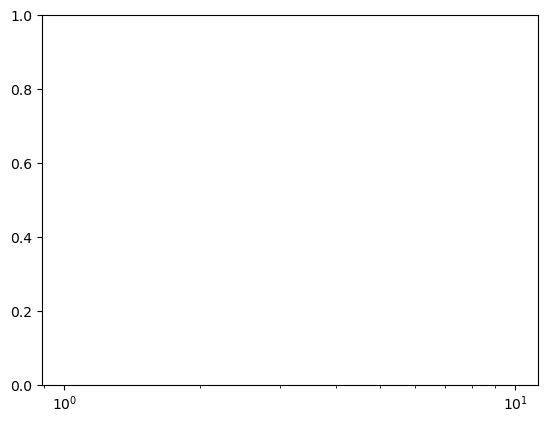

In [12]:
plt.xscale("log")
# plt.xlim(1e-2, 1e7)

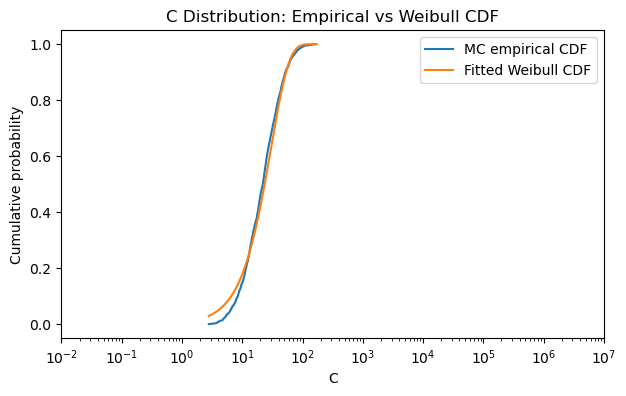

In [13]:
plt.figure(figsize=(7, 4))

plt.plot(C_sorted, empirical_cdf, label="MC empirical CDF")
plt.plot(x, weibull_cdf, label="Fitted Weibull CDF")

plt.xscale("log")
plt.xlim(1e-2, 1e7)

plt.xlabel("C")
plt.ylabel("Cumulative probability")
plt.title("C Distribution: Empirical vs Weibull CDF")
plt.legend()
plt.show()

In [14]:
import rasterio
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

soil_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/soil__texture.tif")

with rasterio.open(soil_path) as src:
    soil = src.read(1)
    nodata = src.nodata

# remove nodata if needed
if nodata is not None:
    soil_values = soil[soil != nodata]
else:
    soil_values = soil.ravel()

# count texture classes
classes, counts = np.unique(soil_values, return_counts=True)

# probability for each class
prob = counts / counts.sum()

texture_names = {
    3: "sandy loam",
    4: "loam",
    7: "sandy clay loam",
    10: "sandy clay",
}

df_texture = pd.DataFrame({
    "texture_code": classes.astype(int),
    "texture_name": [texture_names.get(int(c), "unknown") for c in classes],
    "count": counts,
    "probability": prob,
    "percent": prob * 100,
})

df_texture

,texture_code,texture_name,count,probability,percent
0,3,sandy loam,400694,0.670214,67.021376
1,4,loam,166503,0.278498,27.849831
2,7,sandy clay loam,12339,0.020639,2.063861
3,10,sandy clay,18324,0.030649,3.064932


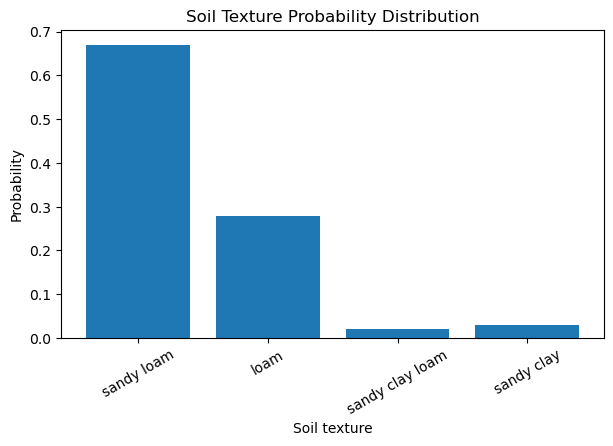

In [15]:
plt.figure(figsize=(7, 4))

plt.bar(
    df_texture["texture_name"],
    df_texture["probability"]
)

plt.ylabel("Probability")
plt.xlabel("Soil texture")
plt.title("Soil Texture Probability Distribution")
plt.xticks(rotation=30)
plt.show()

In [16]:
def make_C_samples(d50_mm, na_min, na_max, r_min, r_max, n_samples=1500, seed=42):
    rng = np.random.default_rng(seed)

    d50_m = d50_mm / 1000
    na_samples = rng.uniform(na_min, na_max, n_samples)
    r_samples = rng.uniform(r_min, r_max, n_samples) / 1000 / 3600

    C_samples = []

    for na, r in zip(na_samples, r_samples):
        C = modeled_threshold_c(d50_m, na, r, cfg["parameters"])
        C_samples.append(float(C))

    return np.array(C_samples)

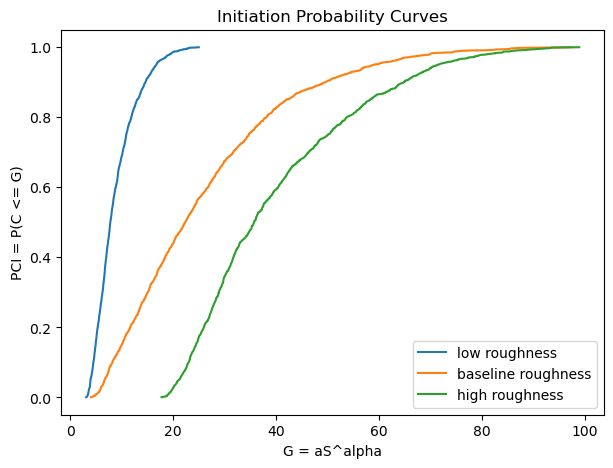

In [17]:
curves = {
    "low roughness": make_C_samples(2.0, 0.01, 0.03, 15, 55),
    "baseline roughness": make_C_samples(2.0, 0.015, 0.10, 15, 55),
    "high roughness": make_C_samples(2.0, 0.07, 0.10, 15, 55),
}

plt.figure(figsize=(7, 5))

for label, C_samples in curves.items():
    C_sorted = np.sort(C_samples)
    probability = np.arange(1, len(C_sorted) + 1) / len(C_sorted)

    plt.plot(C_sorted, probability, label=label)

plt.xlabel("G = aS^alpha")
plt.ylabel("PCI = P(C <= G)")
plt.title("Initiation Probability Curves")
plt.legend()
plt.show()

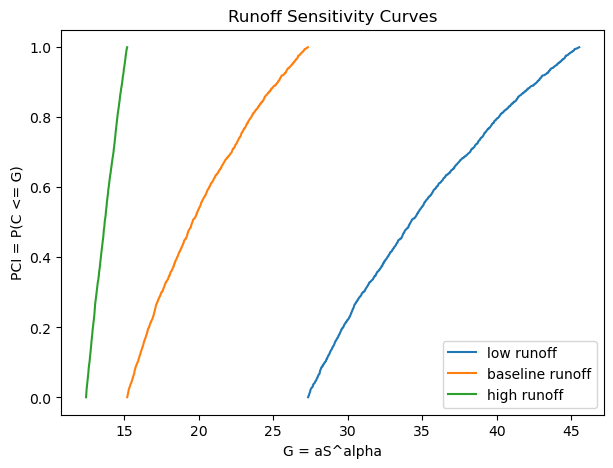

In [18]:
runoff_curves = {
    "low runoff": make_C_samples(2.0, 0.052, 0.052, 15, 25),
    "baseline runoff": make_C_samples(2.0, 0.052, 0.052, 25, 45),
    "high runoff": make_C_samples(2.0, 0.052, 0.052, 45, 55),
}

plt.figure(figsize=(7, 5))

for label, C_samples in runoff_curves.items():
    C_sorted = np.sort(C_samples)
    probability = np.arange(1, len(C_sorted) + 1) / len(C_sorted)
    plt.plot(C_sorted, probability, label=label)

plt.xlabel("G = aS^alpha")
plt.ylabel("PCI = P(C <= G)")
plt.title("Runoff Sensitivity Curves")
plt.legend()
plt.show()

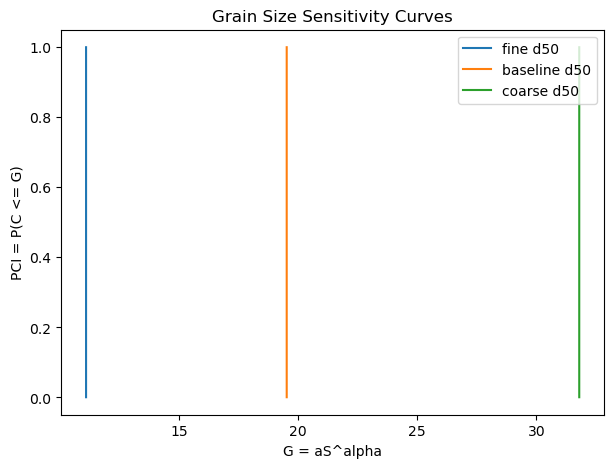

In [19]:
d50_curves = {
    "fine d50": make_C_samples(1.3, 0.052, 0.052, 35, 35),
    "baseline d50": make_C_samples(2.0, 0.052, 0.052, 35, 35),
    "coarse d50": make_C_samples(2.9, 0.052, 0.052, 35, 35),
}

plt.figure(figsize=(7, 5))

for label, C_samples in d50_curves.items():
    C_sorted = np.sort(C_samples)
    probability = np.arange(1, len(C_sorted) + 1) / len(C_sorted)
    plt.plot(C_sorted, probability, label=label)

plt.xlabel("G = aS^alpha")
plt.ylabel("PCI = P(C <= G)")
plt.title("Grain Size Sensitivity Curves")
plt.legend()
plt.show()

In [20]:
from pathlib import Path
import geopandas as gpd
from rasterio.features import geometry_mask

litho_path = Path("/mnt/c/Users/amehedi/Downloads/montecito_litho.shp")

litho = gpd.read_file(litho_path)

# match lithology CRS to raster CRS
litho = litho.to_crs(profile["crs"])

print(litho.columns)
print(litho["MAJOR1"].unique())

Index(['STATE', 'ORIG_LABEL', 'SGMC_LABEL', 'UNIT_LINK', 'UNIT_NAME',
       'AGE_MIN', 'AGE_MAX', 'MAJOR1', 'MAJOR2', 'MAJOR3', 'MINOR1', 'MINOR2',
       'MINOR3', 'MINOR4', 'MINOR5', 'INCIDENTAL', 'INDETERMIN', 'REF_ID',
       'REFERENCE', 'GENERALIZE', 'DIGITAL_UR', 'NGMDB1', 'NGMDB2', 'NGMDB3',
       'Shape_Leng', 'Shape_Area', 'RuleID', 'geometry'],
      dtype='object')
['Mudstone' 'Sandstone' 'Coarse-detrital']


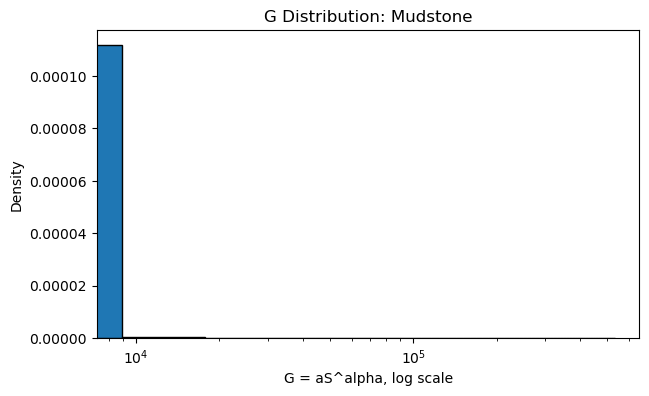

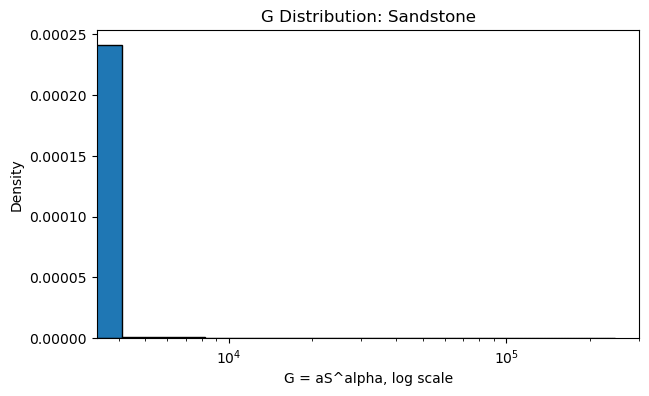

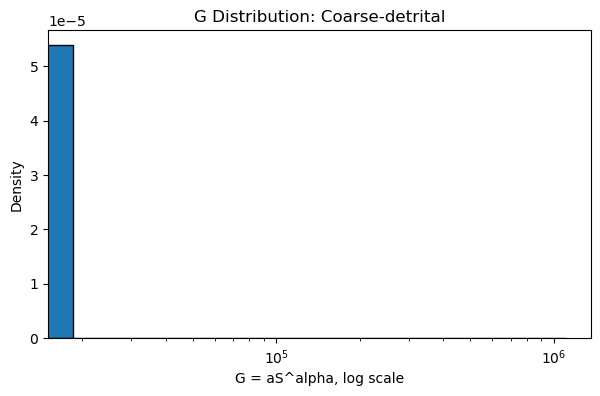

In [21]:
for litho_class in litho["MAJOR1"].dropna().unique():
    geoms = litho[litho["MAJOR1"] == litho_class].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    G_values = G[mask & valid & np.isfinite(G)]
    G_values = G_values[G_values > 0]

    if len(G_values) == 0:
        continue

    plt.figure(figsize=(7, 4))
    plt.hist(
        G_values,
        bins=60,
        density=True,
        edgecolor="black"
    )

    plt.xscale("log")
    plt.xlabel("G = aS^alpha, log scale")
    plt.ylabel("Density")
    plt.title(f"G Distribution: {litho_class}")
    plt.show()

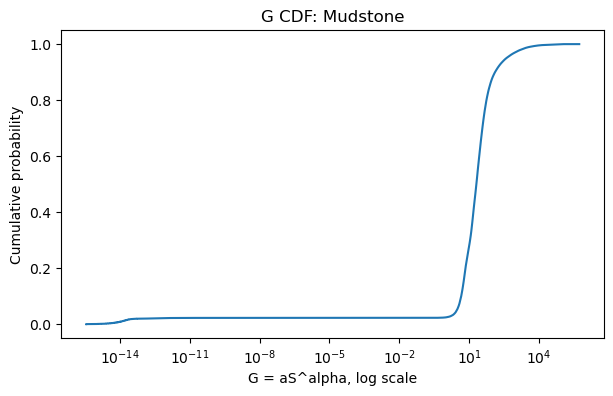

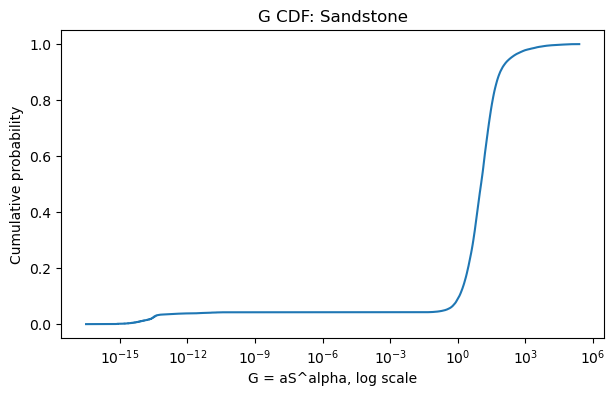

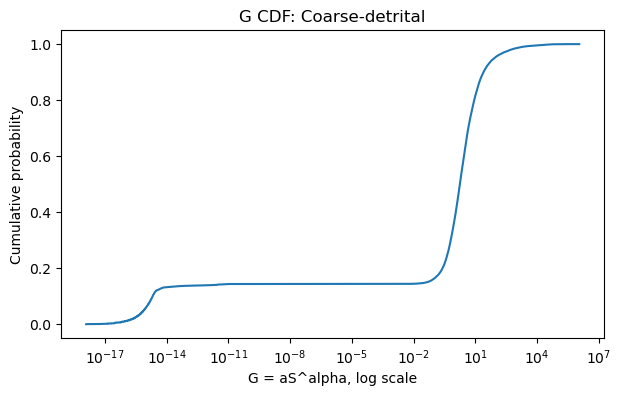

In [22]:
for litho_class in litho["MAJOR1"].dropna().unique():
    geoms = litho[litho["MAJOR1"] == litho_class].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    G_values = G[mask & valid & np.isfinite(G)]
    G_values = G_values[G_values > 0]

    if len(G_values) == 0:
        continue

    G_sorted = np.sort(G_values)
    cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

    plt.figure(figsize=(7, 4))
    plt.plot(G_sorted, cdf)

    plt.xscale("log")
    plt.xlabel("G = aS^alpha, log scale")
    plt.ylabel("Cumulative probability")
    plt.title(f"G CDF: {litho_class}")
    plt.show()

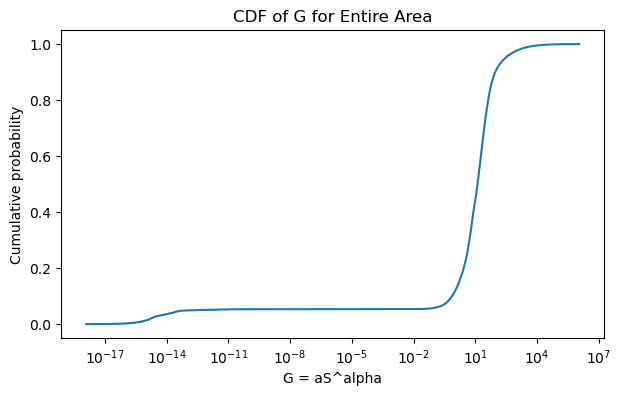

In [23]:
G_values = G[valid & np.isfinite(G)]
G_values = G_values[G_values > 0]

G_sorted = np.sort(G_values)
cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

plt.figure(figsize=(7, 4))
plt.plot(G_sorted, cdf)

plt.xscale("log")
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("CDF of G for Entire Area")
plt.show()

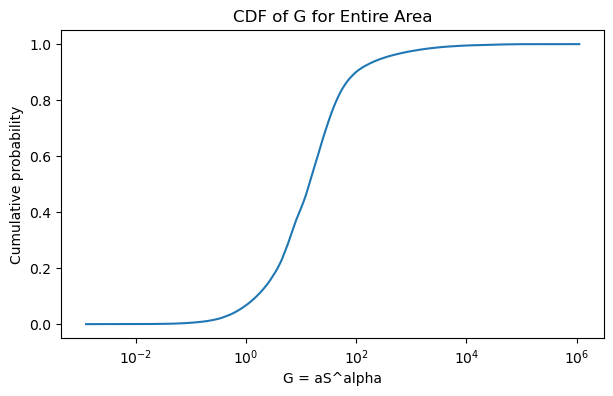

In [24]:
G_values = G[valid & np.isfinite(G)]
G_values = G_values[G_values > 0.001]

G_sorted = np.sort(G_values)
cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

plt.figure(figsize=(7, 4))
plt.plot(G_sorted, cdf)
plt.xscale("log")
plt.xlabel("G = aS^alpha")
plt.ylabel("Cumulative probability")
plt.title("CDF of G for Entire Area")
plt.show()

In [25]:
import geopandas as gpd
import pandas as pd
from rasterio.features import geometry_mask

# 1. Read lithology shapefile
litho_path = Path("/mnt/c/Users/amehedi/Downloads/montecito_litho.shp")

litho = gpd.read_file(litho_path)
litho = litho.to_crs(profile["crs"])

# 2. Make the main C distribution again
rng = np.random.default_rng(42)
n_samples = 1500

d50_samples_mm = rng.lognormal(np.log(2.0), 0.24, n_samples)
na_samples = rng.uniform(0.015, 0.10, n_samples)
r_samples_mm_hr = rng.uniform(15, 55, n_samples)

C_main = []

for d50_mm, na, r_mm_hr in zip(d50_samples_mm, na_samples, r_samples_mm_hr):
    C = modeled_threshold_c(
        d50_mm / 1000,
        na,
        r_mm_hr / 1000 / 3600,
        cfg["parameters"]
    )
    C_main.append(float(C))

C_main = np.array(C_main)
C_sorted = np.sort(C_main)

# 3. Convert every G cell to PCI using C CDF
pci_from_cdf = np.full(G.shape, np.nan)

pci_from_cdf[valid] = np.searchsorted(
    C_sorted,
    G[valid],
    side="right"
) / len(C_sorted)

# 4. Summarize PCI by lithology
rows = []

for litho_class in litho["MAJOR1"].dropna().unique():
    geoms = litho[litho["MAJOR1"] == litho_class].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    values = pci_from_cdf[mask & valid & np.isfinite(pci_from_cdf)]

    if len(values) == 0:
        continue

    rows.append({
        "lithology": litho_class,
        "mean_PCI": np.mean(values),
        "median_PCI": np.median(values),
        "percent_PCI_gt_0_6": 100 * np.mean(values > 0.6),
        "percent_PCI_gt_0_7": 100 * np.mean(values > 0.7),
        "n_cells": len(values),
    })

pci_by_litho = pd.DataFrame(rows)
pci_by_litho

,lithology,mean_PCI,median_PCI,percent_PCI_gt_0_6,percent_PCI_gt_0_7,n_cells
0,Mudstone,0.485093,0.47,41.854371,34.806962,310639
1,Sandstone,0.333449,0.17,26.763067,22.046112,144606
2,Coarse-detrital,0.124066,0.00,9.800229,8.586468,124242


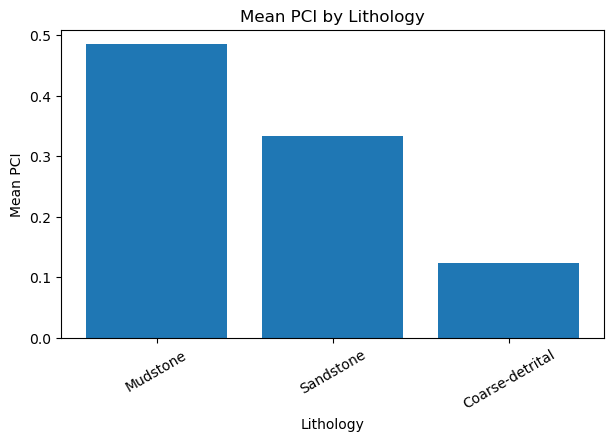

In [26]:
pci_by_litho = pci_by_litho.sort_values("mean_PCI", ascending=False)

plt.figure(figsize=(7, 4))
plt.bar(pci_by_litho["lithology"], pci_by_litho["mean_PCI"])

plt.ylabel("Mean PCI")
plt.xlabel("Lithology")
plt.title("Mean PCI by Lithology")
plt.xticks(rotation=30)
plt.show()

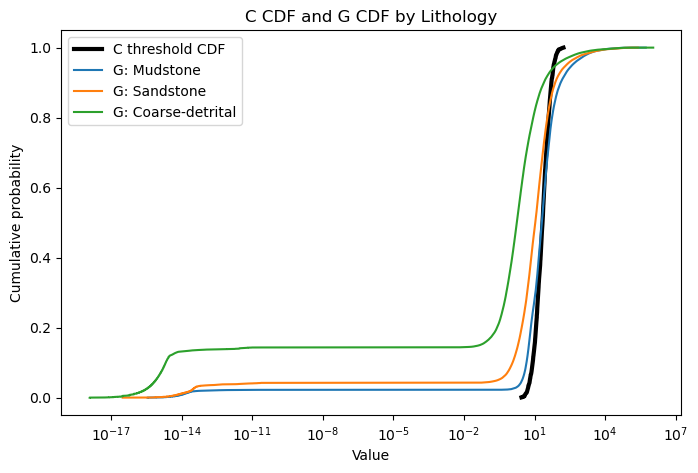

In [27]:
# Main C CDF
C_sorted = np.sort(C_main)
C_cdf = np.arange(1, len(C_sorted) + 1) / len(C_sorted)

plt.figure(figsize=(8, 5))

# Plot C CDF
plt.plot(
    C_sorted,
    C_cdf,
    color="black",
    linewidth=3,
    label="C threshold CDF"
)

# Plot G CDF for each lithology
for litho_class in litho["MAJOR1"].dropna().unique():
    geoms = litho[litho["MAJOR1"] == litho_class].geometry

    mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    G_values = G[mask & valid & np.isfinite(G)]
    G_values = G_values[G_values > 0]

    if len(G_values) == 0:
        continue

    G_sorted = np.sort(G_values)
    G_cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

    plt.plot(G_sorted, G_cdf, label=f"G: {litho_class}")

plt.xscale("log")
plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("C CDF and G CDF by Lithology")
plt.legend()
# plt.xlim(1e-2, 1e7)
plt.show()

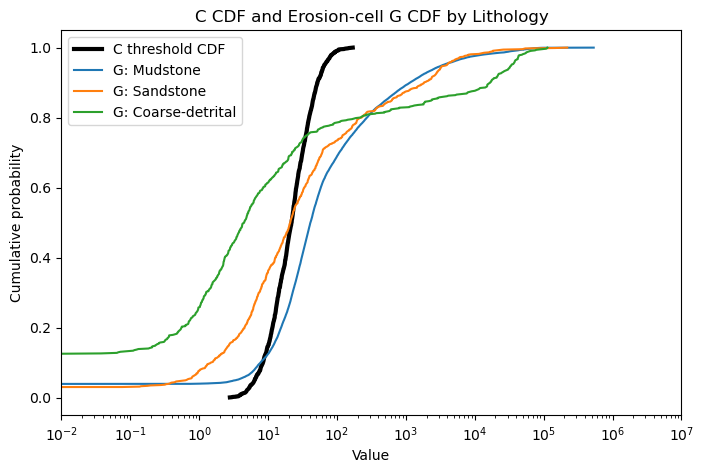

In [28]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.features import geometry_mask

# read DoD / DEM difference
demdiff_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/dem_diff.tif")

with rasterio.open(demdiff_path) as src:
    demdiff = src.read(1)
    demdiff_nodata = src.nodata

if demdiff_nodata is not None:
    demdiff_valid = demdiff != demdiff_nodata
else:
    demdiff_valid = np.isfinite(demdiff)

# erosion cells only
erosion_mask = demdiff_valid & (demdiff <= -0.8)

# C CDF
C_sorted = np.sort(C_main)
C_cdf = np.arange(1, len(C_sorted) + 1) / len(C_sorted)

plt.figure(figsize=(8, 5))

plt.plot(
    C_sorted,
    C_cdf,
    color="black",
    linewidth=3,
    label="C threshold CDF"
)

# G CDF by lithology, erosion cells only
for litho_class in litho["MAJOR1"].dropna().unique():
    geoms = litho[litho["MAJOR1"] == litho_class].geometry

    litho_mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    G_values = G[
        litho_mask
        & erosion_mask
        & valid
        & np.isfinite(G)
    ]

    G_values = G_values[G_values > 0]

    if len(G_values) == 0:
        continue

    G_sorted = np.sort(G_values)
    G_cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

    plt.plot(G_sorted, G_cdf, label=f"G: {litho_class}")

plt.xscale("log")
plt.xlim(1e-2, 1e7)
plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("C CDF and Erosion-cell G CDF by Lithology")
plt.legend()
plt.show()

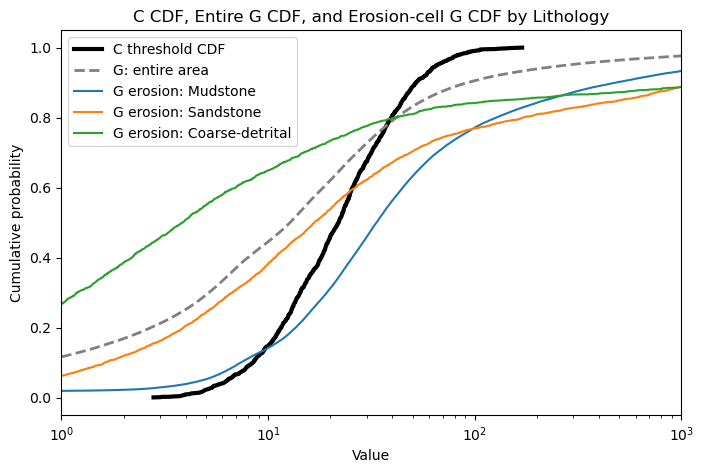

In [29]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.features import geometry_mask

# read DoD / DEM difference
demdiff_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/dem_diff.tif")

with rasterio.open(demdiff_path) as src:
    demdiff = src.read(1)
    demdiff_nodata = src.nodata

if demdiff_nodata is not None:
    demdiff_valid = demdiff != demdiff_nodata
else:
    demdiff_valid = np.isfinite(demdiff)

# erosion cells only
erosion_mask = demdiff_valid & (demdiff <= -0.4)

# C CDF
C_sorted = np.sort(C_main)
C_cdf = np.arange(1, len(C_sorted) + 1) / len(C_sorted)

plt.figure(figsize=(8, 5))

plt.plot(
    C_sorted,
    C_cdf,
    color="black",
    linewidth=3,
    label="C threshold CDF"
)

# entire G CDF
G_all = G[valid & np.isfinite(G)]
G_all = G_all[G_all > 0]

G_all_sorted = np.sort(G_all)
G_all_cdf = np.arange(1, len(G_all_sorted) + 1) / len(G_all_sorted)

plt.plot(
    G_all_sorted,
    G_all_cdf,
    color="gray",
    linewidth=2,
    linestyle="--",
    label="G: entire area"
)

# G CDF by lithology, erosion cells only
for litho_class in litho["MAJOR1"].dropna().unique():
    geoms = litho[litho["MAJOR1"] == litho_class].geometry

    litho_mask = geometry_mask(
        geoms,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    G_values = G[
        litho_mask
        & erosion_mask
        & valid
        & np.isfinite(G)
    ]

    G_values = G_values[G_values > 0]

    if len(G_values) == 0:
        continue

    G_sorted = np.sort(G_values)
    G_cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

    plt.plot(G_sorted, G_cdf, label=f"G erosion: {litho_class}")

plt.xscale("log")
plt.xlim(1, 1000)
plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("C CDF, Entire G CDF, and Erosion-cell G CDF by Lithology")
plt.legend()
plt.show()

In [30]:
from pathlib import Path
import geopandas as gpd
import pandas as pd
from shapely.geometry import Polygon, MultiPolygon

folder = Path("/mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata/watershed_boundaries")

files = list(folder.glob("*.shp"))

gdfs = []

for f in files:
    gdf = gpd.read_file(f)
    gdf["source_file"] = f.stem
    gdfs.append(gdf)

all_watersheds = gpd.GeoDataFrame(
    pd.concat(gdfs, ignore_index=True),
    crs=gdfs[0].crs
)

# dissolve
geom = all_watersheds.geometry.union_all()

# remove holes
def remove_holes(geom):
    if geom.geom_type == "Polygon":
        return Polygon(geom.exterior)

    if geom.geom_type == "MultiPolygon":
        return MultiPolygon([Polygon(part.exterior) for part in geom.geoms])

    return geom

geom_no_holes = remove_holes(geom)

outline = gpd.GeoDataFrame(
    {"name": ["all_watersheds_outline_no_holes"]},
    geometry=[geom_no_holes],
    crs=all_watersheds.crs
)

out_path = Path("/mnt/c/Users/amehedi/Downloads/all_watersheds_outline_no_holes.gpkg")
outline.to_file(out_path, driver="GPKG")

print("saved:", out_path)

saved: /mnt/c/Users/amehedi/Downloads/all_watersheds_outline_no_holes.gpkg


In [31]:
from pathlib import Path
import geopandas as gpd

watershed_path = Path("/mnt/c/Users/amehedi/Downloads/all_watersheds_outline_no_holes.gpkg")
aoi_path = Path("/mnt/c/Users/amehedi/Downloads/montecito_aoi.shp")

watershed = gpd.read_file(watershed_path)
aoi = gpd.read_file(aoi_path)

# make CRS match
aoi = aoi.to_crs(watershed.crs)

# clip watershed by AOI square
watershed_in_aoi = gpd.overlay(
    watershed,
    aoi,
    how="intersection"
)

# save
out_path = Path("/mnt/c/Users/amehedi/Downloads/watershed_outline_within_aoi.gpkg")
watershed_in_aoi.to_file(out_path, driver="GPKG")

print("saved:", out_path)
watershed_in_aoi

saved: /mnt/c/Users/amehedi/Downloads/watershed_outline_within_aoi.gpkg


,name,id,geometry
0,all_watersheds_outline_no_holes,NaN,"POLYGON ((258431.181 3815469.132, 258408.03 38..."


In [32]:
from pathlib import Path
import geopandas as gpd
from shapely.ops import unary_union, polygonize

contacts_folder = Path("/mnt/c/Users/amehedi/Downloads/6gjn2fmz86-3/6gjn2fmz86-3/Rill_Data_GIS_supplement_extracted/commondata/geology_contacts")

boundary_path = Path("/mnt/c/Users/amehedi/Downloads/watershed_outline_within_aoi.gpkg")

# read outside boundary
boundary = gpd.read_file(boundary_path)

# read contact lines
contact_files = [
    contacts_folder / "Juncal_Mat.shp",
    contacts_folder / "Matilija_Cd.shp",
    contacts_folder / "Coldw_Cozyd.shp",
]

lines = []

for f in contact_files:
    gdf = gpd.read_file(f).to_crs(boundary.crs)
    lines.extend(list(gdf.geometry))

# add outside boundary line
boundary_line = boundary.geometry.iloc[0].boundary
lines.append(boundary_line)

# polygonize boundary + contact lines
merged_lines = unary_union(lines)
polygons = list(polygonize(merged_lines))

dunne_polygons = gpd.GeoDataFrame(
    {"poly_id": range(1, len(polygons) + 1)},
    geometry=polygons,
    crs=boundary.crs
)

# keep only polygons inside boundary
dunne_polygons = gpd.overlay(
    dunne_polygons,
    boundary,
    how="intersection"
)

# save
out_path = Path("/mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg")
dunne_polygons.to_file(out_path, driver="GPKG")

print("saved:", out_path)
print("number of polygons:", len(dunne_polygons))

dunne_polygons

saved: /mnt/c/Users/amehedi/Downloads/dunne_lithology_polygons_unlabeled.gpkg
number of polygons: 7


,poly_id,name,id,geometry
0,1,all_watersheds_outline_no_holes,NaN,"POLYGON ((254657.523 3818594.185, 254678.199 3..."
1,2,all_watersheds_outline_no_holes,NaN,"POLYGON ((254657.523 3818594.185, 254652.048 3..."
2,3,all_watersheds_outline_no_holes,NaN,"POLYGON ((259852.554 3816809.678, 259846.783 3..."
3,4,all_watersheds_outline_no_holes,NaN,"POLYGON ((254323.961 3817952.141, 254355.638 3..."
4,5,all_watersheds_outline_no_holes,NaN,"POLYGON ((255383.712 3816832.612, 255439.865 3..."
5,6,all_watersheds_outline_no_holes,NaN,"POLYGON ((255613.688 3816748.897, 255659.998 3..."
6,7,all_watersheds_outline_no_holes,NaN,"POLYGON ((259750.278 3815534.083, 259758.023 3..."


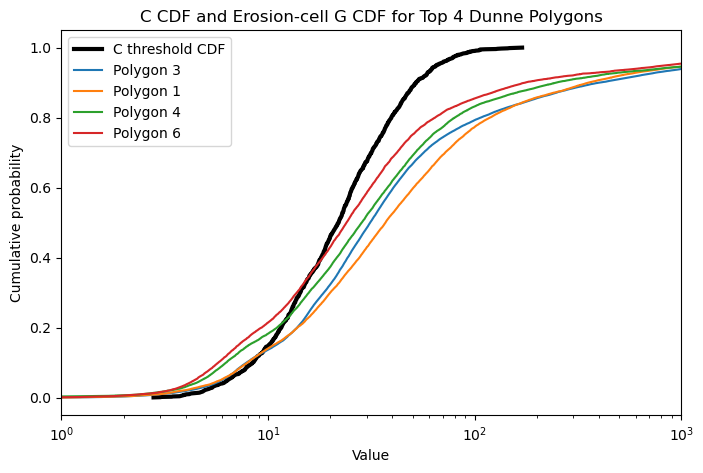

In [33]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from rasterio.features import geometry_mask

# read DEM difference
demdiff_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/dem_diff.tif")

with rasterio.open(demdiff_path) as src:
    demdiff = src.read(1)
    nodata = src.nodata

if nodata is not None:
    demdiff_valid = demdiff != nodata
else:
    demdiff_valid = np.isfinite(demdiff)

# erosion threshold
erosion_mask = demdiff_valid & (demdiff < -0.277)

# top 4 largest polygons
dunne_polygons = dunne_polygons.copy()
dunne_polygons["area"] = dunne_polygons.geometry.area

top4 = dunne_polygons.sort_values("area", ascending=False).head(4)

plt.figure(figsize=(8, 5))

# add C CDF
C_sorted = np.sort(C_main)
C_cdf = np.arange(1, len(C_sorted) + 1) / len(C_sorted)

plt.plot(
    C_sorted,
    C_cdf,
    color="black",
    linewidth=3,
    label="C threshold CDF"
)

# add G CDFs for top 4 polygons
for poly_id in top4["poly_id"]:
    geom = top4[top4["poly_id"] == poly_id].geometry

    poly_mask = geometry_mask(
        geom,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    G_values = G[
        poly_mask
        & erosion_mask
        & valid
        & np.isfinite(G)
    ]

    G_values = G_values[G_values > 0]

    if len(G_values) == 0:
        continue

    G_sorted = np.sort(G_values)
    G_cdf = np.arange(1, len(G_sorted) + 1) / len(G_sorted)

    plt.plot(G_sorted, G_cdf, label=f"Polygon {poly_id}")

plt.xscale("log")
plt.xlim(1, 1000)
plt.xlabel("Value")
plt.ylabel("Cumulative probability")
plt.title("C CDF and Erosion-cell G CDF for Top 4 Dunne Polygons")
plt.legend()
plt.show()

In [34]:
import pandas as pd
from rasterio.features import geometry_mask

cell_area_m2 = abs(profile["transform"].a * profile["transform"].e)

rows = []

for poly_id in dunne_polygons["poly_id"]:
    geom = dunne_polygons[dunne_polygons["poly_id"] == poly_id].geometry

    mask = geometry_mask(
        geom,
        out_shape=G.shape,
        transform=profile["transform"],
        invert=True
    )

    pixel_count = int((mask & valid).sum())
    area_m2 = pixel_count * cell_area_m2

    rows.append({
        "poly_id": poly_id,
        "pixel_count": pixel_count,
        "area_m2": area_m2,
        "area_km2": area_m2 / 1_000_000,
    })

polygon_area_table = pd.DataFrame(rows)

polygon_area_table

,poly_id,pixel_count,area_m2,area_km2
0,1,41773,4177300.0,4.1773
1,2,0,0.0,0.0000
2,3,82574,8257400.0,8.2574
3,4,34167,3416700.0,3.4167
4,5,55,5500.0,0.0055
5,6,23624,2362400.0,2.3624
6,7,62,6200.0,0.0062


Top 5% PCI cutoff: 0.024666666666666667
source pixels: 93082
source area m2: 9308200.0


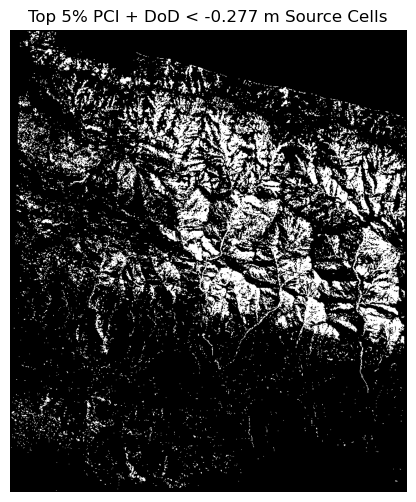

saved: /mnt/c/Users/amehedi/Downloads/top70_pci_dod_source_binary.tif


In [45]:
import rasterio
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# ---------- 1. PCI from C CDF ----------
C_sorted = np.sort(C_main)

pci_map = np.full(G.shape, np.nan)

pci_map[valid] = np.searchsorted(
    C_sorted,
    G[valid],
    side="right"
) / len(C_sorted)

# ---------- 2. Top 5% PCI cutoff ----------
pci_cutoff = np.nanpercentile(pci_map[valid], 30)

top5_mask = pci_map >= pci_cutoff

print("Top 5% PCI cutoff:", pci_cutoff)

# ---------- 3. Read DoD / DEM difference ----------
demdiff_path = Path("/mnt/c/Users/amehedi/Downloads/thomas/dem_diff.tif")

with rasterio.open(demdiff_path) as src:
    demdiff = src.read(1)
    demdiff_nodata = src.nodata

if demdiff_nodata is not None:
    demdiff_valid = demdiff != demdiff_nodata
else:
    demdiff_valid = np.isfinite(demdiff)

# ---------- 4. Erosion threshold ----------
erosion_mask = demdiff_valid & (demdiff < -0.277)

# ---------- 5. Final binary source map ----------
source_binary = (top5_mask & erosion_mask & valid).astype("uint8")

print("source pixels:", source_binary.sum())
print("source area m2:", source_binary.sum() * cell_area_m2)

# ---------- 6. Plot ----------
plt.figure(figsize=(8, 6))
plt.imshow(source_binary, cmap="gray")
plt.title("Top 5% PCI + DoD < -0.277 m Source Cells")
plt.axis("off")
plt.show()

# ---------- 7. Save GeoTIFF ----------
out_path = Path("/mnt/c/Users/amehedi/Downloads/top70_pci_dod_source_binary.tif")

out_profile = profile.copy()
out_profile.update(
    dtype="uint8",
    count=1,
    nodata=0,
    compress="deflate"
)

with rasterio.open(out_path, "w", **out_profile) as dst:
    dst.write(source_binary, 1)

print("saved:", out_path)